# TFM – Clasificación de tipos tumorales a partir de datos de expresión génica

## T2. Obtención de los datos, control de calidad (QC) y análisis exploratorio (PCA/UMAP)

**Autora:** Ona Sánchez Núñez

**Dataset:** *Gene expression cancer RNA-Seq* (Fiorini, 2016), UCI Machine Learning Repository ([doi:10.24432/C5R88H](https://doi.org/10.24432/C5R88H)), licencia CC BY 4.0. Procede del proyecto TCGA Pan-Cancer (Weinstein et al., 2013).

La primera vez que se ejecuta, el notebook descarga los datos en la carpeta `Dataset/UCI`. Las figuras se guardan en la carpeta `figuras/`.

### Librerías y configuración

In [20]:
import tarfile
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import umap

%matplotlib inline

SEED = 1234  # semilla para que los resultados sean reproducibles

DATA_DIR = Path("Dataset/UCI")
FIG_DIR = Path("figuras")
FIG_DIR.mkdir(exist_ok=True)

# Colores: uno para cada tipo
CLASES = ["BRCA", "COAD", "KIRC", "LUAD", "PRAD"]
COLORES = {"BRCA": "#a1c9f4", "COAD": "#ffb482", "KIRC": "#8de5a1",
           "LUAD": "#ff9f9b", "PRAD": "#d0bbff"}
COLOR_1_SERIE = "#a1c9f4"  # para figuras de una sola serie

## 1. Obtención de los datos

In [21]:
carpeta = DATA_DIR / "TCGA-PANCAN-HiSeq-801x20531"

# Los datos solo se descargan la primera vez
if not (carpeta / "data.csv").exists():
    print("Descargando el dataset...")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    url = "https://archive.ics.uci.edu/static/public/401/gene+expression+cancer+rna+seq.zip"
    urllib.request.urlretrieve(url, DATA_DIR / "datos.zip")
    # El zip contiene los dos CSV
    with zipfile.ZipFile(DATA_DIR / "datos.zip") as z:
        z.extractall(DATA_DIR)
    with tarfile.open(DATA_DIR / "TCGA-PANCAN-HiSeq-801x20531.tar.gz") as t:
        t.extractall(DATA_DIR)

X = pd.read_csv(carpeta / "data.csv", index_col=0)
y = pd.read_csv(carpeta / "labels.csv", index_col=0)["Class"]

print("data.csv:", X.shape[0], "muestras x", X.shape[1], "genes")
print("labels.csv:", y.shape[0], "etiquetas")
X.iloc[:5, :6]

data.csv: 801 muestras x 20531 genes
labels.csv: 801 etiquetas


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0


801 muestras y 20.531 genes

## 2. Control de calidad (QC)

In [22]:
# Comprobar que las muestras de data.csv y labels.csv coinciden
print("Mismas muestras y en el mismo orden:", X.index.equals(y.index))

# Valores faltantes y duplicados
print("Valores faltantes:", X.isna().sum().sum())
print("Muestras duplicadas:", X.duplicated().sum())

# Rango de los valores y porcentaje de ceros
print("Valor mínimo:", X.min().min())
print("Valor máximo:", round(X.max().max(), 2))
print("Porcentaje de ceros:", round((X == 0).mean().mean() * 100, 1), "%")

# Genes sin variación (tienen el mismo valor en todas las muestras)
varianza = X.var()
genes_var0 = varianza[varianza == 0].index
print("Genes con varianza 0:", len(genes_var0))

Mismas muestras y en el mismo orden: True
Valores faltantes: 0
Muestras duplicadas: 0
Valor mínimo: 0.0
Valor máximo: 20.78
Porcentaje de ceros: 14.2 %
Genes con varianza 0: 267


**Resultado:**
- Los datos están limpios: no hay valores faltantes ni muestras duplicadas, y las muestras de `data.csv` y `labels.csv` coinciden y están en el mismo orden.
- Los valores van de 0 a 20,78
- Hay 267 genes con varianza 0 (0 en todas las muestras). No aportan información por lo que se eliminarán dentro de la pipeline.

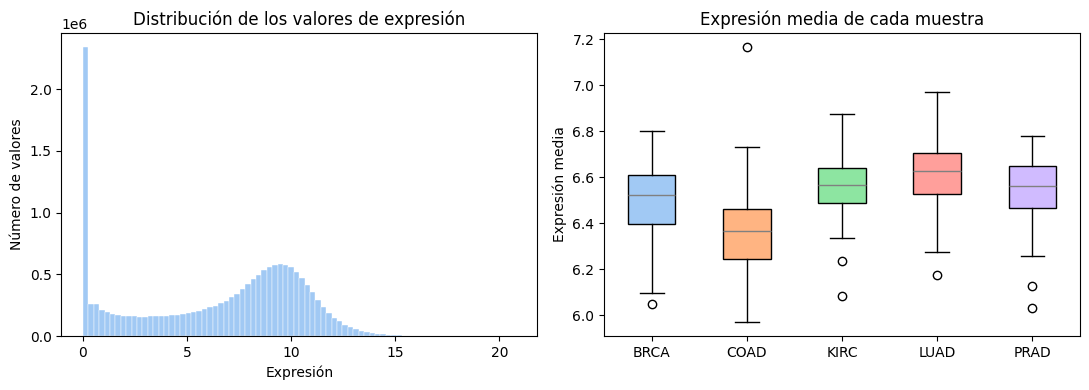

       count  mean   std   min   25%   50%   75%   max
Class                                                 
BRCA   300.0  6.50  0.15  6.05  6.40  6.52  6.61  6.80
COAD    78.0  6.38  0.18  5.97  6.24  6.37  6.46  7.17
KIRC   146.0  6.56  0.12  6.08  6.49  6.57  6.64  6.87
LUAD   141.0  6.62  0.14  6.17  6.53  6.63  6.71  6.97
PRAD   136.0  6.55  0.13  6.03  6.47  6.56  6.65  6.78


In [24]:
# Se quitan los genes sin variación porque no aportan información
X_ok = X.drop(columns=genes_var0)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))

# Histograma
axs[0].hist(X.values.flatten(), bins=80, color=COLOR_1_SERIE, edgecolor="white", linewidth=0.3)
axs[0].set_title("Distribución de los valores de expresión")
axs[0].set_xlabel("Expresión")
axs[0].set_ylabel("Número de valores")

# Expresión media de cada muestra, por tipo tumoral
media_muestra = X_ok.mean(axis=1)
cajas = axs[1].boxplot([media_muestra[y == c] for c in CLASES], patch_artist=True,
                       medianprops={"color": "gray"})
for caja, c in zip(cajas["boxes"], CLASES):
    caja.set_facecolor(COLORES[c])
axs[1].set_xticks(range(1, 6), CLASES)
axs[1].set_title("Expresión media de cada muestra")
axs[1].set_ylabel("Expresión media")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_qc.png", dpi=150)
plt.show()

print(media_muestra.groupby(y).describe().round(2))

**Resultado:**
- El histograma tiene la forma típica de datos RNA-seq en escala log2: un pico en 0 (el 14,2 % de los valores son genes que no se expresan) y el resto de valores concentrados entre 5 y 13 aproximadamente.
- La expresión media de cada muestra es muy parecida en los cinco tipos tumorales (medianas entre 6,4 y 6,6) y no hay ninguna muestra muy alejada del resto. No se ven problemas técnicos, así que no se elimina ninguna muestra.

## 3. Análisis exploratorio

### 3.1 Distribución de clases

Class
BRCA    300
KIRC    146
LUAD    141
PRAD    136
COAD     78
Name: count, dtype: int64
Ratio clase mayor / clase menor: 3.8


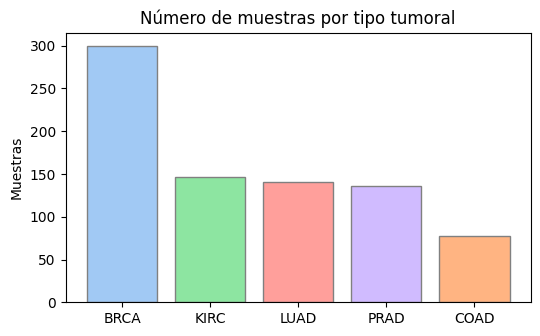

In [25]:
conteo = y.value_counts()
print(conteo)
print("Ratio clase mayor / clase menor:", round(conteo.max() / conteo.min(), 1))

plt.figure(figsize=(6, 3.5))
plt.bar(conteo.index, conteo.values, color=[COLORES[c] for c in conteo.index], edgecolor="gray")
plt.title("Número de muestras por tipo tumoral")
plt.ylabel("Muestras")
plt.savefig(FIG_DIR / "fig2_clases.png", dpi=150)
plt.show()

--> Clases desequilibradas: BRCA 300 muestras (37,5 %), COAD solo 78 (9,7 %). Por eso en la validación se usarán particiones estratificadas y la métrica F1 macro, que da el mismo peso a cada clase.

### 3.2 PCA

Con todos los datos para visualizar

Varianza explicada por PC1: 10.5 %
Varianza explicada por PC2: 8.8 %
Varianza explicada por las 10 primeras PCs: 46.6 %
Varianza explicada por las 50 PCs: 63.7 %


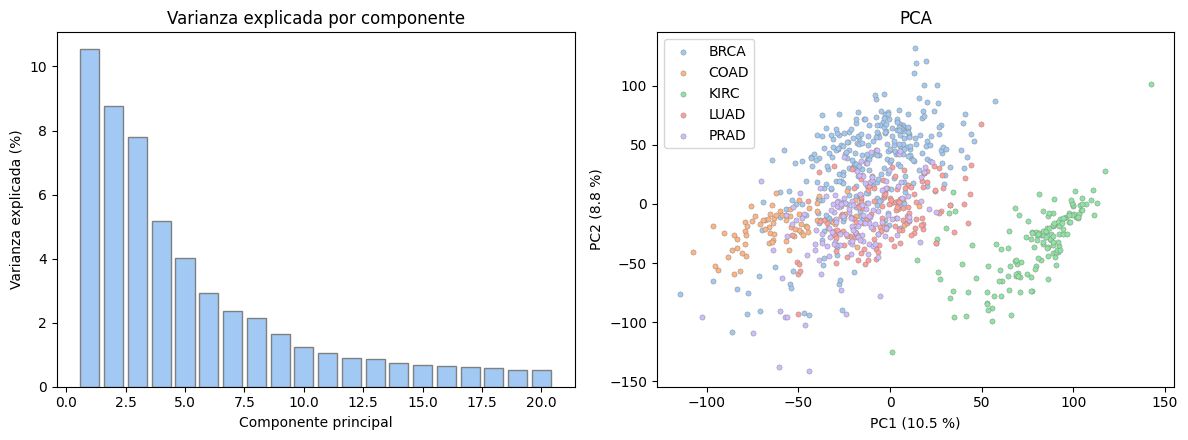

In [26]:
# Se estandarizan los genes (media 0 y desviación 1) antes del PCA
X_esc = StandardScaler().fit_transform(X_ok)

pca = PCA(n_components=50, random_state=SEED)
X_pca = pca.fit_transform(X_esc)
var_exp = pca.explained_variance_ratio_ * 100

print("Varianza explicada por PC1:", round(var_exp[0], 1), "%")
print("Varianza explicada por PC2:", round(var_exp[1], 1), "%")
print("Varianza explicada por las 10 primeras PCs:", round(var_exp[:10].sum(), 1), "%")
print("Varianza explicada por las 50 PCs:", round(var_exp.sum(), 1), "%")

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))

# Varianza explicada por las 20 primeras componentes
axs[0].bar(range(1, 21), var_exp[:20], color=COLOR_1_SERIE, edgecolor="gray")
axs[0].set_title("Varianza explicada por componente")
axs[0].set_xlabel("Componente principal")
axs[0].set_ylabel("Varianza explicada (%)")

# Muestras en el plano PC1-PC2
for c in CLASES:
    m = (y == c).values
    axs[1].scatter(X_pca[m, 0], X_pca[m, 1], s=14, color=COLORES[c], edgecolor="gray", linewidth=0.3, label=c)
axs[1].set_title("PCA")
axs[1].set_xlabel(f"PC1 ({var_exp[0]:.1f} %)")
axs[1].set_ylabel(f"PC2 ({var_exp[1]:.1f} %)")
axs[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_pca.png", dpi=150)
plt.show()

- Varianza muy repartida: PC1 y PC2 explican juntas solo un 19,3 %, las 10 primeras componentes un 46,6 % y las 50 un 63,7 %.
- En el gráfico PC1 y PC2, KIRC se separa claramente del resto, BRCA queda en la parte superior y COAD a la izquierda. LUAD y PRAD se solapan entre sí y con BRCA en el centro.
- Con dos componentes no basta para separar todas las clases.

### 3.3 UMAP

El UMAP se calcula sobre las 50 primeras componentes del PCA --> más rápido y reduce el ruido.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


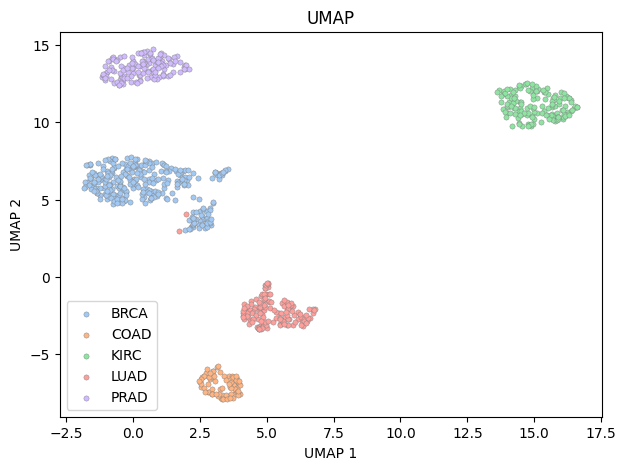

In [27]:
reductor = umap.UMAP(n_neighbors=15, min_dist=0.3, random_state=SEED)
X_umap = reductor.fit_transform(X_pca)

plt.figure(figsize=(7, 5))
for c in CLASES:
    m = (y == c).values
    plt.scatter(X_umap[m, 0], X_umap[m, 1], s=14, color=COLORES[c], edgecolor="gray", linewidth=0.3, label=c)
plt.title("UMAP")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.savefig(FIG_DIR / "fig4_umap.png", dpi=150)
plt.show()

El UMAP muestra cinco grupos bien separados, uno por tipo tumoral, así que las clases sí tienen perfiles de expresión distintos aunque en el PCA no se viera del todo.

### 3.4 Heatmap de los 500 genes más variables

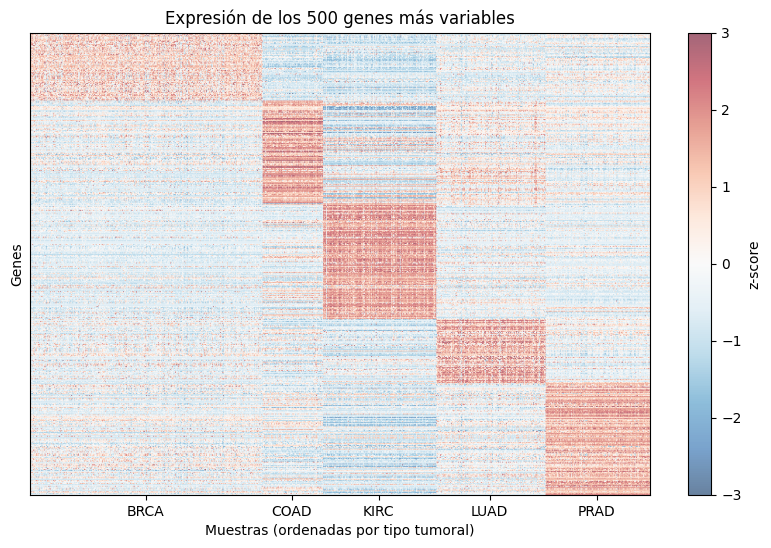

Genes del top 500 con la expresión media más alta en cada tipo tumoral:
KIRC    125
PRAD    121
COAD    111
BRCA     74
LUAD     69
Name: count, dtype: int64


In [18]:
top500 = X_ok.var().sort_values(ascending=False).index[:500]
orden_muestras = y.sort_values().index
datos = X_ok.loc[orden_muestras, top500]

# z-score de cada gen, para poder comparar genes con niveles de expresión distintos
datos = (datos - datos.mean()) / datos.std()

# Se ordenan los genes según el tipo tumoral en el que tienen la expresión media más alta
clase_max = datos.groupby(y).mean().idxmax()
datos = datos[clase_max.sort_values().index]

plt.figure(figsize=(10, 6))
# alpha < 1 suaviza los colores (tonos pastel)
plt.imshow(datos.T, aspect="auto", cmap="RdBu_r", vmin=-3, vmax=3, alpha=0.6)
plt.colorbar(label="z-score")
# Etiqueta de cada tipo tumoral en el centro de su bloque de muestras
posiciones = [np.where(y[orden_muestras] == c)[0].mean() for c in CLASES]
plt.xticks(posiciones, CLASES)
plt.yticks([])
plt.title("Expresión de los 500 genes más variables")
plt.xlabel("Muestras (ordenadas por tipo tumoral)")
plt.ylabel("Genes")
plt.savefig(FIG_DIR / "fig5_heatmap.png", dpi=150)
plt.show()

print("Genes del top 500 con la expresión media más alta en cada tipo tumoral:")
print(clase_max.value_counts())

- Cada tipo tumoral tiene un bloque de genes que se expresan más en esa clase que en el resto (bloques rojos). Los más claros son los de KIRC, COAD, LUAD y PRAD. KIRC tiene además genes menos expresados que en el resto de clases (zonas azules).
- En BRCA el bloque es menos marcado, lo que coincide con que en el UMAP aparezca dividido en dos subgrupos.
- Los genes están anonimizados (`gene_X`), así que no se puede interpretar su función biológica (riesgo R3 de la PEC1).

## 4. Conclusión

Los datos tienen buena calidad: no hay valores faltantes ni duplicados y no hace falta eliminar muestras. Solo hay que quitar los 267 genes sin variación, cosa que se hará dentro de la pipeline. Las clases están desequilibradas, lo que justifica la validación estratificada y el uso del F1 macro. Los cinco tipos tumorales tienen perfiles de expresión claramente diferentes, por lo que es esperable que los modelos obtengan un rendimiento muy alto (riesgo R4 de la PEC1).